<img src="https://www.unir.net/wp-content/uploads/2019/11/Unir_2021_logo.svg" width="240" height="240" align="right"/>

<center><h1>Técnicas de Inteligencia Artificial</header1></center>
<left><h1>Actividad 2. Trabajando con redes neuronales y Deep Learning</header1></left>

Presentado por: Maria Pais Fajin  <br>
Fecha: 20/05/2026

# Importación de librerias necesarias

# Parte II. Clasificación

In [1]:
#Para esta actividad se importarán las siguientes librerías:
# Librerías estándar de análisis y visualizacion
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocesamiento, división y modelos alternativos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, f1_score, ConfusionMatrixDisplay)

# TensorFlow / Keras para la red neuronal
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import set_random_seed
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score
from tensorflow.keras.callbacks import EarlyStopping



## Cargar el Dataset

Dataset con 50.005 instancias, 17 atributos y 11 clases de salida.

In [2]:
# URL del dataset alojado en repositorio público de GitHub
# Fuente original: https://www.kaggle.com/datasets/purumalgi/music-genre-classification
url = 'https://raw.githubusercontent.com/Finarosalina/music-genre-classification/refs/heads/main/train.csv'

# Carga con Pandas
df = pd.read_csv(url)

print(f"Dataset cargado: {df.shape[0]:,} instancias × {df.shape[1]} columnas")
df.head(3)

Dataset cargado: 17,996 instancias × 17 columnas


,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,Bruno Mars,That's What I Like (feat. Gucci Mane),60.0,0.854,0.564,1.0,-4.964,1,0.0485,0.0171,NaN,0.0849,0.899,134.071,234596.0,4,5
1,Boston,Hitch a Ride,54.0,0.382,0.814,3.0,-7.230,1,0.0406,0.0011,0.004010,0.1010,0.569,116.454,251733.0,4,10
2,The Raincoats,No Side to Fall In,35.0,0.434,0.614,6.0,-8.334,1,0.0525,0.4860,0.000196,0.3940,0.787,147.681,109667.0,4,6


## Descripción de la fuente del Dataset

El dataset utilizado es **Music Genre Classification**, disponible públicamente en Kaggle 
([enlace](https://www.kaggle.com/datasets/purumalgi/music-genre-classification)) y alojado en 
GitHub para su descarga directa sin autenticación.

Los datos corresponden a características de audio extraídas mediante la API de Spotify para 
canciones de distintos géneros musicales. Cada instancia representa una canción descrita mediante 
atributos acústicos numéricos estandarizados por Spotify (danceability, energy, loudness, etc.) 
y una etiqueta de clase (género) codificada numéricamente del 0 al 10.

| Clase | Género |
|-------|--------|
| 0 | Acoustic |
| 1 | Alt-Rock |
| 2 | Blues |
| 3 | Bollywood |
| 4 | Country |
| 5 | HipHop |
| 6 | IndiePop |
| 7 | Instrumental |
| 8 | Metal |
| 9 | Pop |
| 10 | Rock |

## Caracterización del dataset
El dataset cuenta con **17.996 instancias** y **17 columnas**, de las que 14 son features de entrada numéricas (float64 o int64), 2 son identificadores de texto (Artist Name, Track Name) y 1 es la variable objetivo (Class).

La variable objetivo `Class` es de tipo entero y toma 11 valores posibles (0–10), cada uno correspondiente a un género musical: Acoustic, Alt-Rock, Blues, Bollywood, Country, HipHop, IndiePop, Instrumental, Metal, Pop y Rock.

El dataset presenta un **desbalanceo notable**: Rock concentra 4.949 instancias mientras que Bollywood y Country no superan las 400. Esto puede afectar al rendimiento de los modelos en las clases minoritarias.

Del análisis de medias por clase destacan diferencias claras entre géneros: Instrumental presenta una acousticness media de 0.906 y energy de 0.155, valores muy alejados del resto, lo que facilita su identificación. Metal, en cambio, muestra la energy más alta (0.876) y la acousticness más baja (0.027). HipHop lidera en danceability (0.726). Estas diferencias confirman que las features de audio tienen poder discriminativo real entre géneros.

## Problema a resolver
Se trata de un problema de **clasificación multiclase supervisada**: dadas las características de audio de una canción, predecir su género musical entre 11 posibles. Es un problema de clasificación porque la variable objetivo es categórica y discreta, no continua.

La variable objetivo es `Class` (género musical: Acoustic, Alt-Rock, Blues, Bollywood, Country, HipHop, IndiePop, Instrumental, Metal, Pop, Rock). Las variables de entrada son 14 atributos numéricos que Spotify calcula automáticamente para cada canción: Popularity, danceability, energy, key, loudness, mode, speechiness, acousticness, instrumentalness, liveness, valence, tempo, duration y time_signature.

La relación que se trata de comprobar es si las características acústicas cuantificadas por Spotify son suficientes para discriminar géneros musicales de forma automática, sin intervención humana. Una solución precisa tendría aplicación directa en sistemas de catalogación automática de música, motores de recomendación y análisis de tendencias en plataformas de streaming.

Se comparan dos métodos: una **red neuronal artificial** con Keras/TensorFlow y un **Random Forest**, para evaluar si la capacidad de aprendizaje de representaciones de las redes neuronales aporta ventaja frente a un modelo de ensamble clásico en datos tabulares de audio.

In [3]:
# Instancias y atributos
print(f"Instancias: {df.shape[0]}  |  Columnas: {df.shape[1]}")
print(f"Features de entrada: {df.shape[1] - 3}")

# Tipos de variables
print("\nTipo de cada variable:")
print(df.dtypes)

# Clases
print(f"\nNúmero de clases: {df['Class'].nunique()}  |  Tipo: {df['Class'].dtype}")

# Instancias por clase
genre_map = {
    0: 'Acoustic', 1: 'Alt-Rock', 2: 'Blues', 3: 'Bollywood',
    4: 'Country', 5: 'HipHop', 6: 'IndiePop', 7: 'Instrumental',
    8: 'Metal', 9: 'Pop', 10: 'Rock'
}
class_counts = df['Class'].value_counts().sort_index()
class_counts.index = class_counts.index.map(genre_map)
print("\nInstancias por clase:")
print(class_counts)

# Estadísticas de la variable objetivo
print("\nEstadísticas de Class:")
print(df['Class'].describe())

# Media de atributos por clase
print("\nMedia de atributos por clase:")
display(df.groupby('Class')[['danceability','energy','loudness',
                              'acousticness','tempo','valence']].mean().round(3))

Instancias: 17996  |  Columnas: 17
Features de entrada: 14

Tipo de cada variable:
Artist Name               str
Track Name                str
Popularity            float64
danceability          float64
energy                float64
key                   float64
loudness              float64
mode                    int64
speechiness           float64
acousticness          float64
instrumentalness      float64
liveness              float64
valence               float64
tempo                 float64
duration_in min/ms    float64
time_signature          int64
Class                   int64
dtype: object

Número de clases: 11  |  Tipo: int64

Instancias por clase:
Class
Acoustic         625
Alt-Rock        1373
Blues           1272
Bollywood        402
Country          387
HipHop          1447
IndiePop        2587
Instrumental     576
Metal           1854
Pop             2524
Rock            4949
Name: count, dtype: int64

Estadísticas de Class:
count    17996.000000
mean         6.695821
s

,danceability,energy,loudness,acousticness,tempo,valence
Class,,,,,,
0,0.526,0.435,-10.240,0.580,120.204,0.383
1,0.537,0.688,-7.781,0.189,124.873,0.505
2,0.561,0.578,-9.055,0.389,122.749,0.613
3,0.498,0.521,-10.214,0.728,113.520,0.627
4,0.596,0.600,-8.487,0.313,123.003,0.613
5,0.726,0.643,-7.470,0.202,117.940,0.546
6,0.553,0.654,-8.250,0.229,123.230,0.487
7,0.426,0.155,-18.797,0.906,106.332,0.230
8,0.412,0.876,-5.893,0.027,128.339,0.320


In [4]:
#  Mostrar valores nulos 
print(df.isnull().sum())

Artist Name              0
Track Name               0
Popularity             428
danceability             0
energy                   0
key                   2014
loudness                 0
mode                     0
speechiness              0
acousticness             0
instrumentalness      4377
liveness                 0
valence                  0
tempo                    0
duration_in min/ms       0
time_signature           0
Class                    0
dtype: int64


In [5]:
df.describe()

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
count,17568.000000,17996.000000,17996.000000,15982.000000,17996.000000,17996.000000,17996.000000,17996.000000,13619.000000,17996.000000,17996.000000,17996.000000,1.799600e+04,17996.000000,17996.000000
mean,44.512124,0.543433,0.662777,5.952447,-7.910660,0.636753,0.079707,0.247082,0.177562,0.196170,0.486208,122.623294,2.007445e+05,3.924039,6.695821
std,17.426928,0.166268,0.235373,3.196854,4.049151,0.480949,0.083576,0.310632,0.304048,0.159212,0.240195,29.571527,1.119891e+05,0.361618,3.206073
min,1.000000,0.059600,0.000020,1.000000,-39.952000,0.000000,0.022500,0.000000,0.000001,0.011900,0.018300,30.557000,5.016500e-01,1.000000,0.000000
25%,33.000000,0.432000,0.509000,3.000000,-9.538000,0.000000,0.034800,0.004300,0.000089,0.097500,0.297000,99.620750,1.663370e+05,4.000000,5.000000
50%,44.000000,0.545000,0.700000,6.000000,-7.016000,1.000000,0.047400,0.081400,0.003910,0.129000,0.481000,120.065500,2.091600e+05,4.000000,8.000000
75%,56.000000,0.659000,0.860000,9.000000,-5.189000,1.000000,0.083000,0.434000,0.200000,0.258000,0.672000,141.969250,2.524900e+05,4.000000,10.000000
max,100.000000,0.989000,1.000000,11.000000,1.355000,1.000000,0.955000,0.996000,0.996000,1.000000,0.986000,217.416000,1.477187e+06,5.000000,10.000000


Las estadísticas descriptivas muestran que la mayoría de features están acotadas entre 0 y 1 (danceability, energy, speechiness, acousticness, instrumentalness, liveness, valence), mientras que loudness oscila entre -39.9 y 1.4 dB y tempo entre 30 y 217 BPM. La popularidad media es 44.5 sobre 100. Destacan la alta variabilidad de instrumentalness (std=0.304) y acousticness (std=0.311), lo que indica que estas variables discriminan bien entre géneros. La duración presenta un valor mínimo anómalo (0.5 ms) que probablemente corresponde a un error en los datos originales.

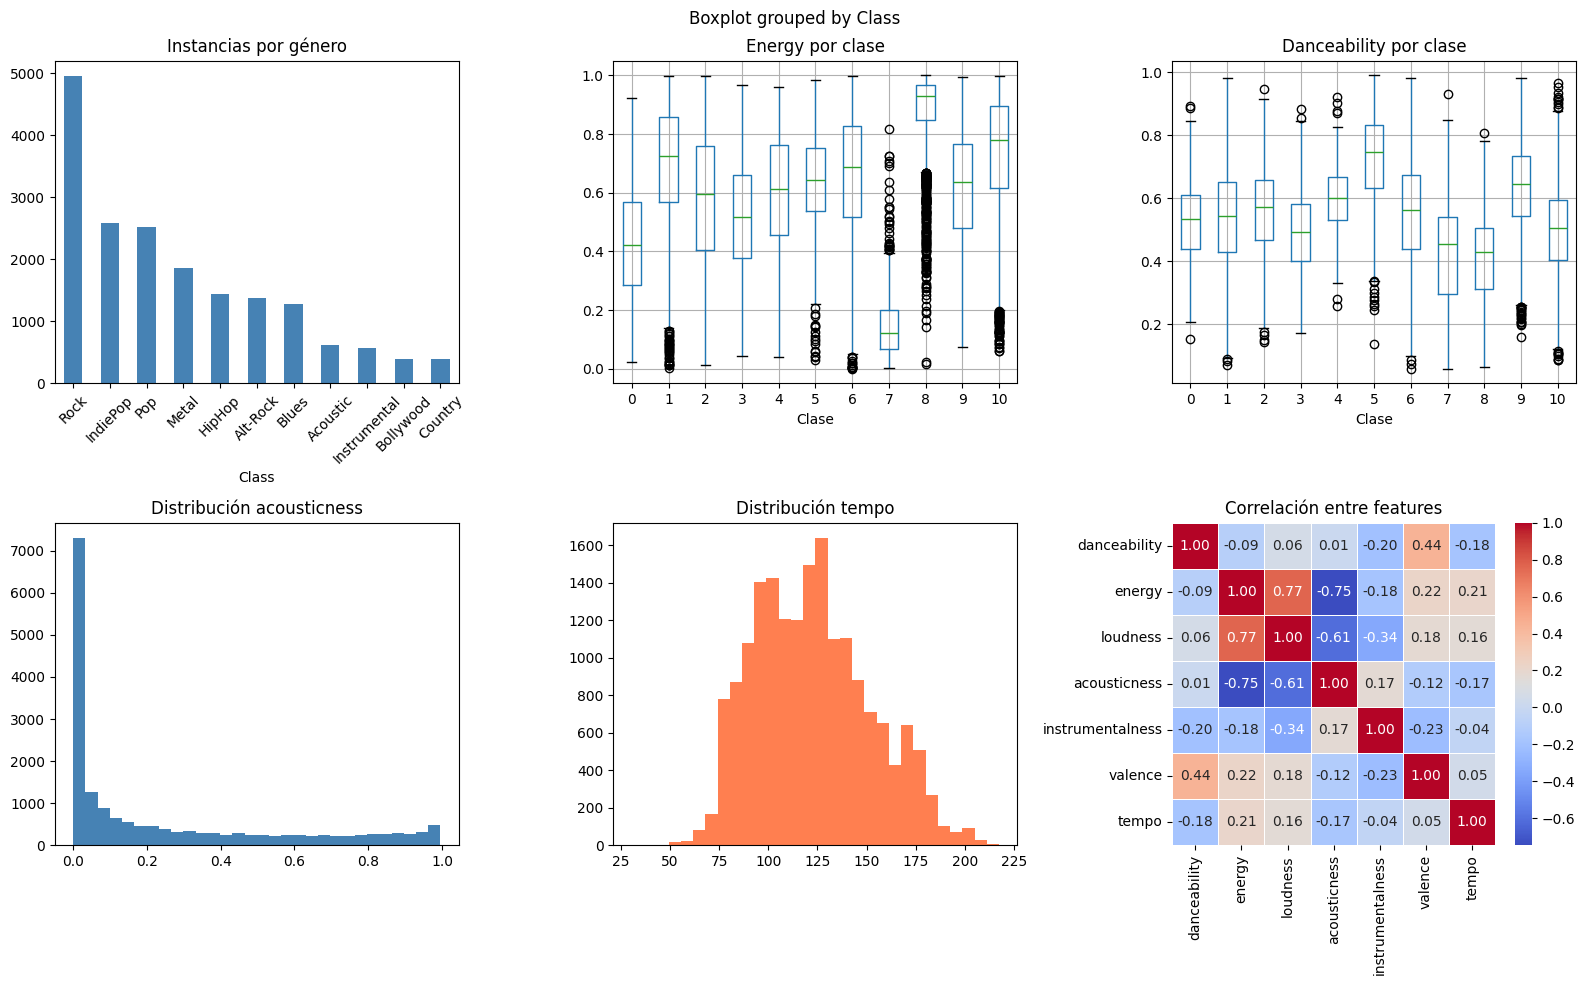

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Distribución de clases
df['Class'].map(genre_map).value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Instancias por género')
axes[0,0].tick_params(axis='x', rotation=45)

# Boxplot energy por clase
df.boxplot(column='energy', by='Class', ax=axes[0,1])
axes[0,1].set_title('Energy por clase')
axes[0,1].set_xlabel('Clase')

# Boxplot danceability por clase
df.boxplot(column='danceability', by='Class', ax=axes[0,2])
axes[0,2].set_title('Danceability por clase')
axes[0,2].set_xlabel('Clase')

# Histograma acousticness
axes[1,0].hist(df['acousticness'], bins=30, color='steelblue')
axes[1,0].set_title('Distribución acousticness')

# Histograma tempo
axes[1,1].hist(df['tempo'], bins=30, color='coral')
axes[1,1].set_title('Distribución tempo')

# Correlación (solo numéricas)
numeric_cols = ['danceability','energy','loudness','acousticness','instrumentalness','valence','tempo']
corr = df[numeric_cols].corr()
sns.heatmap(corr, ax=axes[1,2], cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5)
axes[1,2].set_title('Correlación entre features')

plt.tight_layout()
plt.show()

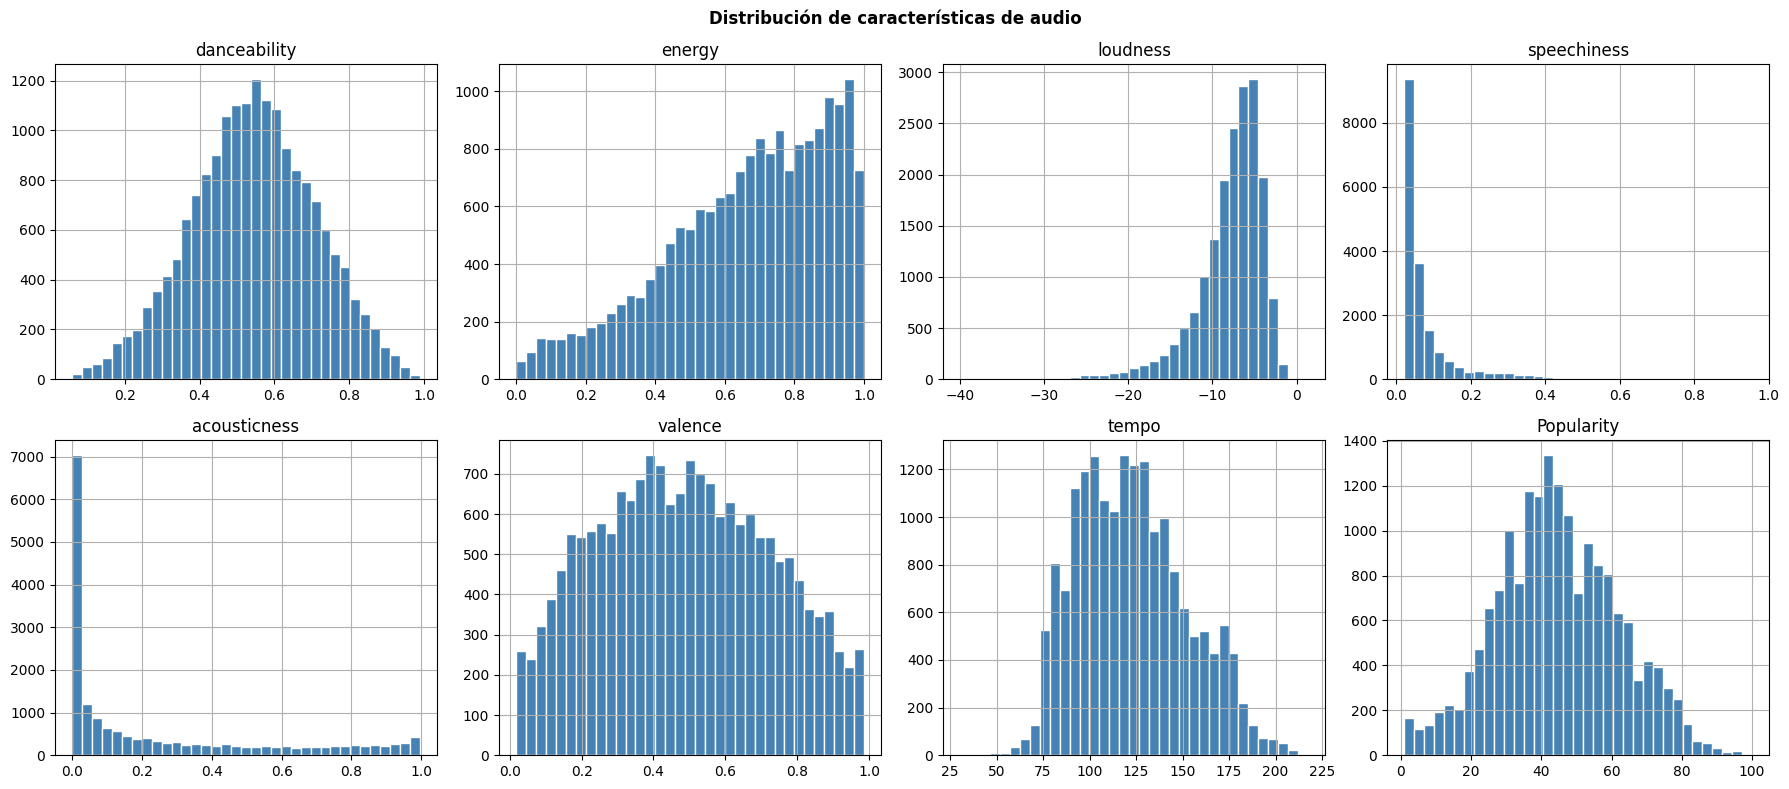

In [7]:
cols = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'valence', 'tempo', 'Popularity']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
df[cols].hist(bins=35, color='steelblue', edgecolor='white', ax=axes)
plt.suptitle('Distribución de características de audio', fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusiones del EDA
Las visualizaciones confirman los hallazgos del análisis numérico. El gráfico de barras evidencia el desbalanceo del dataset: Rock triplica en instancias a géneros como Bollywood o Country, lo que puede penalizar la clasificación de las clases minoritarias.

Los boxplots muestran diferencias claras entre géneros: la clase 7 (Instrumental) presenta una energy notablemente baja y gran concentración de valores, mientras que Metal (clase 8) agrupa los valores más altos. En danceability, HipHop (clase 5) destaca sobre el resto. Ambas variables presentan outliers en prácticamente todas las clases, especialmente en energy donde la clase 7 concentra numerosos valores atípicos por encima de su rango intercuartílico — canciones instrumentales ocasionalmente energéticas que se alejan del patrón del género.

La distribución de acousticness es fuertemente asimétrica hacia la derecha: la mayoría de canciones tienen valores bajos, con una cola larga de canciones muy acústicas. El tempo sigue una distribución aproximadamente normal centrada en torno a 120 BPM.

Los histogramas de las principales features confirman los patrones detectados: danceability sigue una distribución aproximadamente normal centrada en 0.5, mientras que speechiness y acousticness son fuertemente asimétricas hacia la izquierda — la mayoría de canciones tienen valores bajos, con pocas excepciones de alta presencia vocal o acústica. Energy muestra una distribución sesgada hacia valores altos, lo que refleja que el dataset está dominado por géneros eléctricos. Loudness se concentra entre -15 y -5 dB con cola izquierda larga. Valence y tempo se distribuyen de forma más uniforme. Popularity presenta una distribución irregular con un pico en torno a 40-60, posiblemente relacionado con el sesgo de las canciones disponibles en Spotify hacia popularidad media-alta.

El heatmap de correlación muestra que energy y loudness están fuertemente correlacionadas (0.77), mientras que acousticness y energy presentan correlación negativa (-0.75), lo esperado: canciones más acústicas tienden a ser menos energéticas. Estas relaciones tienen sentido musical y confirman que las features contienen información útil para la clasificación.

El análisis visual se ha realizado sobre las 14 features numéricas disponibles. En la etapa de preprocesado se eliminarán las filas con valores nulos en Popularity (428), key (2.014) e instrumentalness (4.377), reduciendo el dataset de 17.996 a aproximadamente 13.000 instancias útiles para el modelado. Los outliers detectados no se eliminan, ya que en datos de audio pueden representar canciones legítimamente atípicas dentro de su género.

Las columnas Artist Name y Track Name son identificadores de texto que, aunque el artista podría ser un predictor relevante del género, se eliminan en el preprocesado: su codificación introduciría alta dimensionalidad y el modelo no generalizaría a artistas no vistos durante el entrenamiento.


## Preprocesamiento del dataset. Transformaciones previas necesarias para la modelación

In [8]:
# 1. Eliminar columnas de texto

cols_drop = ['Artist Name', 'Track Name']
df_model = df.drop(columns=cols_drop)
print(f"Columnas eliminadas: {cols_drop}")

# 2. Eliminar nulos
print(f"Filas antes de dropna: {len(df_model):,}")
df_model = df_model.dropna()
print(f"Filas después de dropna: {len(df_model):,}")

# 3. Separar X e y
X = df_model.drop(columns=['Class'])
y = df_model['Class'].astype(int) # necesitamos que sea numérica para los modelos
print(f"\nFeatures de entrada ({X.shape[1]}): {list(X.columns)}")

Columnas eliminadas: ['Artist Name', 'Track Name']
Filas antes de dropna: 17,996
Filas después de dropna: 11,813

Features de entrada (14): ['Popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_in min/ms', 'time_signature']


Tras eliminar las columnas de texto y las filas con valores nulos en Popularity, key e instrumentalness, el dataset queda reducido a **11.813 instancias**, lo que supone una pérdida del 34% respecto al total original. Dado que el enunciado establece como requisito mínimo 1.000 instancias y el dataset resultante supera ampliamente ese umbral, se considera que la eliminación directa es suficiente para los objetivos del ejercicio.

## División del dataset en datos de entrenamiento y datos de test 

In [9]:
# 4. Dividir en train / val / test (70/15/15), primero separamos el train del resto, y luego dividimos el resto en val y test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# 5. Escalar (estandarizamos todas las varibles numericas) — fit solo en train, así evitamos data leakage   
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]:,} instancias")
print(f"Val:   {X_val.shape[0]:,} instancias")
print(f"Test:  {X_test.shape[0]:,} instancias")

Train: 8,269 instancias
Val:   1,772 instancias
Test:  1,772 instancias


## Propuesta de arquitectura de red neuronal

La red neuronal propuesta es de tipo feedforward secuencial con 3 capas ocultas y una capa de salida:

- **Capa de entrada:** 14 neuronas, una por cada feature de audio.
- **Primera capa oculta:** 64 neuronas con activación ReLU.
- **Segunda capa oculta:** 32 neuronas con activación ReLU.
- **Tercera capa oculta:** 16 neuronas con activación ReLU.
- **Capa de salida:** 11 neuronas con activación Softmax, una por cada género musical.

La arquitectura sigue una estructura decreciente (64→32→16) que reduce progresivamente la dimensionalidad hasta llegar a las 11 clases de salida. Como función de activacion en las capas ocultas se usa ReLU y Softmax en la capa de salida, apropiada para clasificaiones multiclass. Como optimizador se utiliza Adam con la función de pérdida `sparse_categorical_crossentropy`, adecuada para clasificación multiclase con etiquetas enteras.

In [ ]:
# Código de la estructuración de la red
set_random_seed(42)  # para reproducibilidad, para que siempre se genere la misma red con los mismos pesos iniciales
    
model = Sequential()
model.add(Dense(64, input_shape=(14,), activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(11, activation='softmax'))

model.summary()

c:\Users\purdi\anaconda3\envs\Tecnicas_IA\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           187 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,755 (14.67 KB)

 Trainable params: 3,755 (14.67 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Para compilar el modelo, utilizamos 'sparse_categorical_crossentropy' como función de pérdida, para clasificación multiclase con etiquetas enteras. 
# El optimizador 'adam' para la función de optimización
# la métrica 'accuracy' nos permitirá evaluar el rendimiento del modelo durante el entrenamiento.

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model

<Sequential name=sequential, built=True>

In [ ]:
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1)

Epoch 1/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2640 - loss: 1.8096 - val_accuracy: 0.3634 - val_loss: 1.6684
Epoch 2/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3692 - loss: 1.2620 - val_accuracy: 0.4029 - val_loss: 1.5525
Epoch 3/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3976 - loss: 1.1762 - val_accuracy: 0.4300 - val_loss: 1.5073
Epoch 4/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4137 - loss: 1.1338 - val_accuracy: 0.4368 - val_loss: 1.4847
Epoch 5/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4223 - loss: 1.1065 - val_accuracy: 0.4407 - val_loss: 1.4752
Epoch 6/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4329 - loss: 1.0870 - val_accuracy: 0.4396 - val_loss: 1.4673
Epoch 7/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4390 - loss: 1.0719 - val_accuracy: 0.4458 - val_loss: 1.4616
Epoch 8/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4407 - loss: 1.0590 - val_accu

Los resultados obtenidos son consistentes con los reportados por otros usuarios en Kaggle para este mismo dataset. Los notebooks más votados, que utilizan Random Forest con imputación de nulos en lugar de eliminación, obtienen accuracies en torno al 56-60% con modelos de ML clásico (Gradient Boosting: 0.5646, Random Forest con 100 estimadores: ~0.58). El notebook que compara distintos optimizadores de redes neuronales (SGD, Adam, RMSprop, Adagrad, AdamW) concluye que Adam ofrece la mejor convergencia, lo que valida nuestra elección.

Esto indica que el techo de accuracy de este dataset con features de audio tabulares está en torno al 55-65%, independientemente del modelo utilizado. La causa principal es el solapamiento acústico entre géneros similares (Rock/Alt-Rock, Acoustic/IndiePop) y el desbalanceo de clases. Una mejora significativa requeriría features adicionales.

Durante el desarrollo se exploraron distintas configuraciones para mejorar el rendimiento de la RNA: arquitecturas más profundas (256→128→64), Dropout para regularización, class_weight para corregir el desbalanceo, y eliminación de variables correlacionadas (loudness). Ninguna de estas modificaciones mejoró de forma significativa el val_accuracy, lo que refuerza la conclusión de que la limitación es intrínseca al dataset y no a la arquitectura del modelo.

### Progreso de entrenamiento del modelo y estadísticas de evaluación para los conjuntos de entrenamiento y validación.


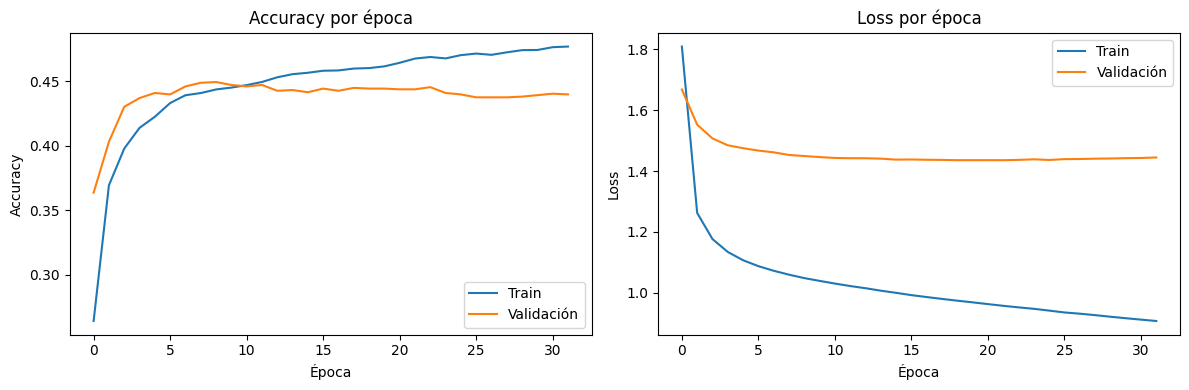

In [23]:
#Código de evaluación de la red propuesta (entrenamiento y validación)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Accuracy por época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Loss por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Las curvas de entrenamiento muestran un patrón de overfitting moderado: la accuracy de train sigue creciendo hasta ~48% mientras que la de validación se estabiliza en torno al 44% desde la época 10. La loss de train desciende de forma continua pero la de validación se estanca alrededor de 1.45, lo que indica que el modelo memoriza los datos de entrenamiento sin generalizar bien. Esto es consistente con las limitaciones del dataset discutidas anteriormente: el solapamiento acústico entre géneros limita la capacidad de generalización independientemente de la arquitectura empleada.

In [24]:
print(f"Train accuracy final:      {history.history['accuracy'][-1]:.4f}")
print(f"Validación accuracy final: {history.history['val_accuracy'][-1]:.4f}")
print(f"Train loss final:          {history.history['loss'][-1]:.4f}")
print(f"Validación loss final:     {history.history['val_loss'][-1]:.4f}")
print(f"Mejor val_accuracy:        {max(history.history['val_accuracy']):.4f}")
print(f"Mejor val_loss:            {min(history.history['val_loss']):.4f}")
print(f"Épocas entrenadas:         {len(history.history['loss'])}")

Train accuracy final:      0.4767
Validación accuracy final: 0.4396
Train loss final:          0.9066
Validación loss final:     1.4446
Mejor val_accuracy:        0.4492
Mejor val_loss:            1.4357
Épocas entrenadas:         32


El modelo entrenó durante 32 épocas antes de que EarlyStopping detuviera el proceso. La accuracy final en train fue 0.4767 frente a 0.4396 en validación, y la loss de train 0.9066 frente a 1.4446 en validación. El mejor val_accuracy alcanzado fue 0.4492 y el mejor val_loss 1.4357, ambos en épocas tempranas, lo que confirma el sobreajuste observado en las curvas: el modelo deja de generalizar pasada la época 10 aproximadamente.

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test accuracy: 0.4391

Classification Report:
              precision    recall  f1-score   support

    Acoustic       0.62      0.52      0.57        58
    Alt-Rock       0.21      0.14      0.17       155
       Blues       0.36      0.63      0.46       143
   Bollywood       0.65      0.76      0.70        41
     Country       0.31      0.77      0.44        22
      HipHop       0.38      0.63      0.47        78
    IndiePop       0.38      0.31      0.34       306
Instrumental       0.95      0.90      0.93        70
       Metal       0.54      0.64      0.59       228
         Pop       0.33      0.48      0.39       165
        Rock       0.50      0.31      0.38       506

    accuracy                           0.44      1772
   macro avg       0.48      0.55      0.49      1772
weighted avg       0.45      0.44      0.43      1772



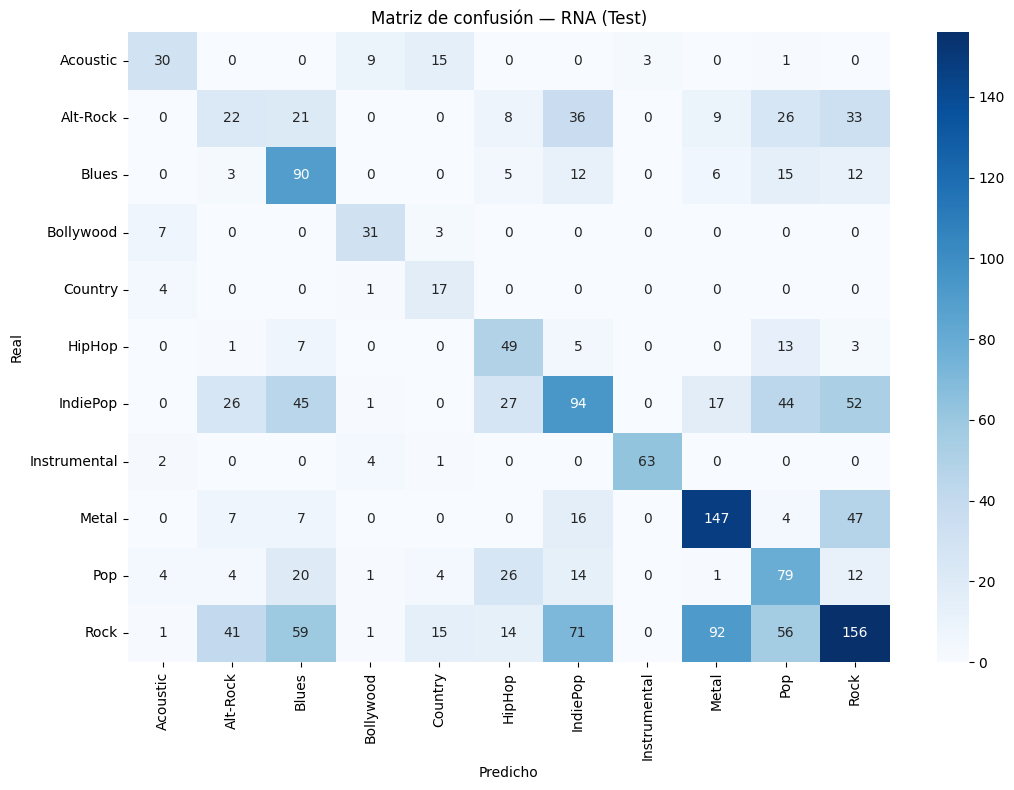

In [25]:
#Código de evaluación de la red propuesta (evaluación conjunto de test)

y_pred = np.argmax(model.predict(X_test), axis=1)

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[genre_map[i] for i in range(11)]))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(11, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[genre_map[i] for i in range(11)],
            yticklabels=[genre_map[i] for i in range(11)])
plt.title('Matriz de confusión — RNA (Test)')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

La evaluación sobre el conjunto de test confirma los resultados obtenidos en validación, con una accuracy del 43.91% y un F1-score macro de 0.49.

El modelo clasifica bien géneros con características acústicas muy diferenciadas: Instrumental con F1=0.93 y Bollywood con F1=0.70. 

En el extremo opuesto, Alt-Rock obtiene F1=0.17, IndiePop y Rock — géneros acústicamente solapados. Rock, a pesar de ser la clase mayoritaria, solo alcanza F1=0.38 porque el modelo confunde muchas instancias con Blues (59) e IndiePop (71).

La matriz de confusión revela que los errores se concentran en el bloque Rock/Alt-Rock/Blues/IndiePop, géneros que comparten rangos similares de energy, danceability y tempo. Esto confirma que la limitación no es la arquitectura sino la capacidad discriminativa de las features de audio para estos géneros específicos.

## Ajuste de modelos de clasificación alternativos

Elige al menos un método de clasificación no basado en redes neuronales (p.ej. regresión logística, árboles de decisión, reglas de clasificación, random forest, SVM, etc).

Test accuracy: 0.4543

Classification Report:
              precision    recall  f1-score   support

    Acoustic       0.66      0.83      0.73        58
    Alt-Rock       0.05      0.03      0.03       155
       Blues       0.39      0.29      0.34       143
   Bollywood       0.82      0.68      0.75        41
     Country       0.74      0.64      0.68        22
      HipHop       0.58      0.46      0.51        78
    IndiePop       0.32      0.30      0.31       306
Instrumental       0.94      0.96      0.95        70
       Metal       0.62      0.54      0.58       228
         Pop       0.43      0.33      0.37       165
        Rock       0.42      0.58      0.49       506

    accuracy                           0.45      1772
   macro avg       0.54      0.51      0.52      1772
weighted avg       0.44      0.45      0.44      1772



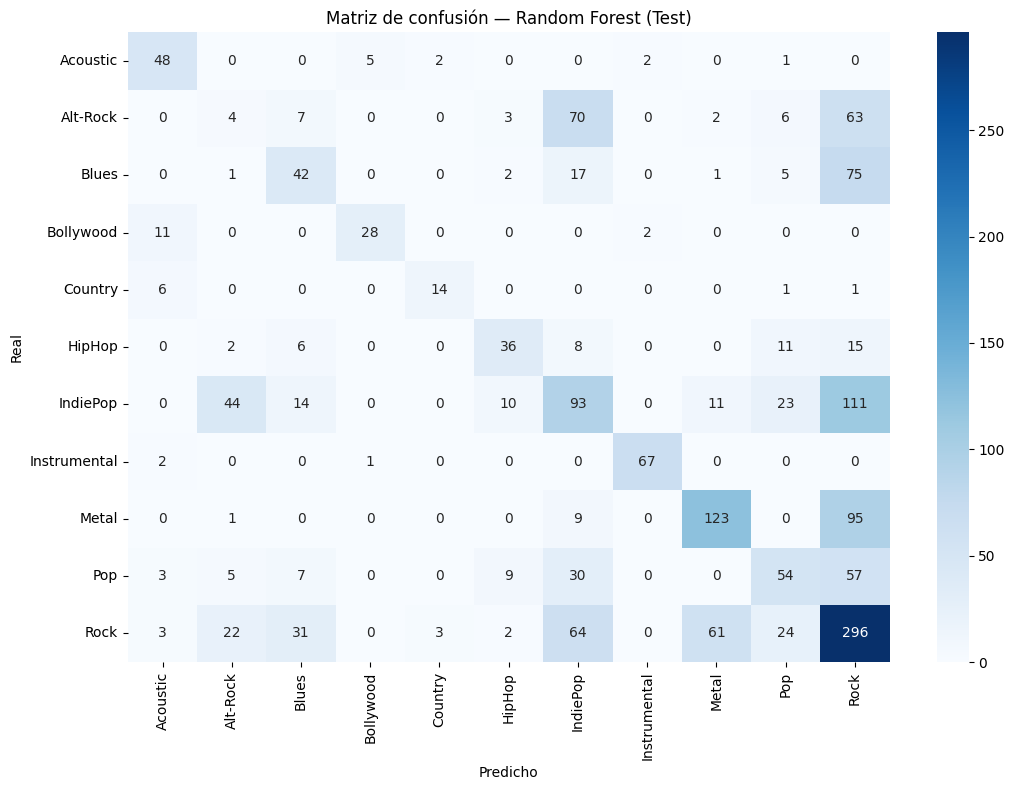

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(f"Test accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=[genre_map[i] for i in range(11)]))

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(11, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=[genre_map[i] for i in range(11)],
            yticklabels=[genre_map[i] for i in range(11)])
plt.title('Matriz de confusión — Random Forest (Test)')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

In [27]:
#Código de ajuste del modelo 2
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_dist, n_iter=10, cv=3,
    scoring='accuracy', random_state=42, verbose=1
)
search.fit(X_train, y_train)
print(f"Mejores parámetros: {search.best_params_}")
print(f"Mejor accuracy CV: {search.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Mejores parámetros: {'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 10}
Mejor accuracy CV: 0.5077


In [28]:
#Código para mostrar la evaluación de los modelos
best_rf = search.best_estimator_
y_pred_rf_best = best_rf.predict(X_test)

print(f"Test accuracy (mejor RF): {accuracy_score(y_test, y_pred_rf_best):.4f}")
print(classification_report(y_test, y_pred_rf_best, target_names=[genre_map[i] for i in range(11)]))

Test accuracy (mejor RF): 0.4904
              precision    recall  f1-score   support

    Acoustic       0.63      0.84      0.72        58
    Alt-Rock       0.50      0.01      0.03       155
       Blues       0.49      0.23      0.31       143
   Bollywood       0.88      0.71      0.78        41
     Country       0.60      0.41      0.49        22
      HipHop       0.58      0.45      0.51        78
    IndiePop       0.41      0.33      0.37       306
Instrumental       0.94      0.94      0.94        70
       Metal       0.65      0.57      0.60       228
         Pop       0.50      0.28      0.36       165
        Rock       0.41      0.73      0.52       506

    accuracy                           0.49      1772
   macro avg       0.60      0.50      0.51      1772
weighted avg       0.51      0.49      0.46      1772



Aplicando RandomizedSearchCV con 10 combinaciones de hiperparámetros y validación cruzada, los mejores parámetros encontrados fueron `n_estimators=200`, `max_depth=10` y `min_samples_split=10`. Limitar la profundidad máxima de los árboles a 10 niveles actúa como regularización, evitando que cada árbol memorice el conjunto de entrenamiento y mejorando la generalización. `min_samples_split=10` exige al menos 10 muestras para dividir un nodo, lo que reduce la sensibilidad al ruido.

El modelo optimizado alcanza una accuracy de 49.04% en test, el mejor resultado obtenido en este ejercicio. La precision macro sube a 0.60, indicando que cuando el modelo predice un género tiende a acertar. Sin embargo Alt-Rock sigue siendo problemático (F1=0.03) por su confusión con Rock e IndiePop, y Blues presenta recall bajo (0.23). Instrumental y Bollywood mantienen buenos resultados (F1=0.94 y 0.78 respectivamente).

## Comparación del desempeño de modelos

Muestra los resultados obtenidos por los diferentes algoritmos escogidos de forma gráfica y comparada/superpuesta.

In [29]:
#Código para mostrar la comparación de métricas de desempeño de las dos propuestas en tabla
results = pd.DataFrame({
    'Modelo': ['RNA', 'Random Forest', 'RF Optimizado'],
    'Accuracy': [0.4391, 0.4543, 0.4904],
    'F1-Score (macro)': [0.49, 0.52, 0.51],
    'Precision (macro)': [0.48, 0.54, 0.60]
}).set_index('Modelo')

display(results.style.highlight_max(color='lightgreen', axis=0))

,Accuracy,F1-Score (macro),Precision (macro)
Modelo,,,
RNA,0.439100,0.490000,0.480000
Random Forest,0.454300,0.520000,0.540000
RF Optimizado,0.490400,0.510000,0.600000


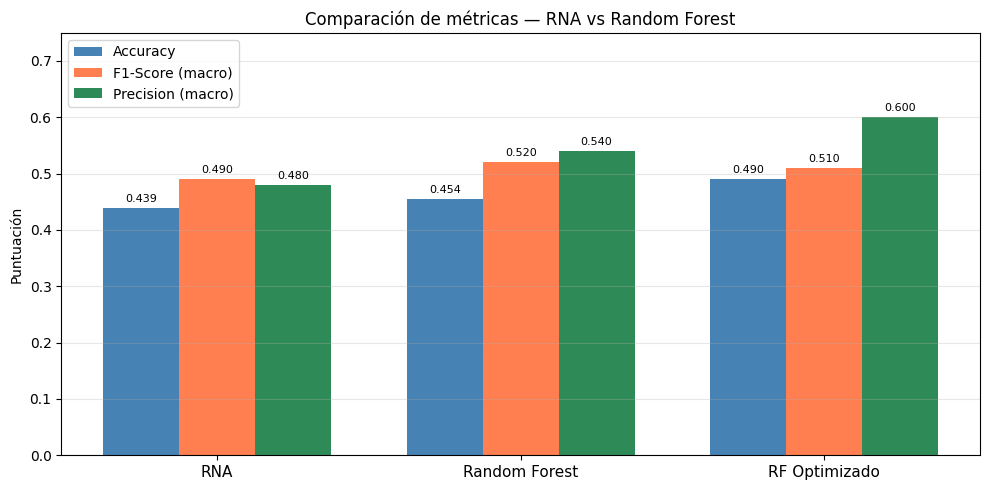

In [30]:
#Código para mostrar la comparación de métricas de desempeño de las dos propuestas en gráfica
x = np.arange(len(results.index))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, results['Accuracy'], width, label='Accuracy', color='steelblue')
ax.bar(x, results['F1-Score (macro)'], width, label='F1-Score (macro)', color='coral')
ax.bar(x + width, results['Precision (macro)'], width, label='Precision (macro)', color='seagreen')

ax.set_xticks(x)
ax.set_xticklabels(results.index, fontsize=11)
ax.set_ylim(0, 0.75)
ax.set_ylabel('Puntuación')
ax.set_title('Comparación de métricas — RNA vs Random Forest')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)

plt.tight_layout()
plt.show()

La comparación entre los tres modelos muestra que el Random Forest optimizado obtiene la mejor accuracy (49.04%) y precision macro (0.60), seguido del Random Forest base (45.43%) y la RNA (43.91%). En F1-Score macro las diferencias son menores: RF base 0.52, RF optimizado 0.51 y RNA 0.49. En conjunto, los modelos basados en árboles superan a la red neuronal en este problema. En datasets tabulares de bajo tamaño, la potencia de aprendizaje que ofrecen las redes para interpretar realciones profundas, no tiene demasiada aplicacion, como coloquialmente se dice, es matar moscas a cañonazos.
## Discusión de resultados

Los tres modelos convergen en torno al 44-49% de accuracy, lo que refleja un techo inherente al dataset más que una limitación de los modelos. Los géneros Instrumental y Bollywood se clasifican bien en todos los modelos (F1>0.70) gracias a sus características acústicas distintivas. El bloque Rock/Alt-Rock/Blues/IndiePop concentra la mayoría de errores en los tres casos, confirmando que estas clases son acústicamente indistinguibles con las features disponibles.

El RF optimizado con RandomizedSearchCV mejora la accuracy pero no el F1 macro respecto al RF base, lo que indica que la regularización por profundidad ayuda globalmente pero no resuelve el problema de las clases difíciles. La RNA, a pesar de su mayor capacidad teórica de representación, no supera a los modelos de ensamble en datos tabulares con este nivel de desbalanceo y solapamiento entre clases.

Los resultados de la RNA podrían mejorarse mediante: (1) optimización de hiperparámetros con Keras Tuner sobre número de capas, neuronas y tasa de aprendizaje; (2) Batch Normalization entre capas para estabilizar el entrenamiento y reducir el overfitting observado y (3) aumento del conjunto de datos mediante técnicas de oversampling como SMOTE sobre las clases minoritarias antes del entrenamiento. Estas mejoras son independientes de si la RNA supera o no al Random Forest, ya que el objetivo es maximizar su capacidad de generalización dentro de las limitaciones del dataset.